In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Manjitha S Kariyawas\OneDrive\Desktop\customer_churn_data.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 104.5 KB


In [5]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
df["InternetService"] = df["InternetService"].fillna("")

In [7]:
df.isna().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [10]:
numeric_columns_data = df.select_dtypes(include = ["number"])

In [11]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [12]:
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

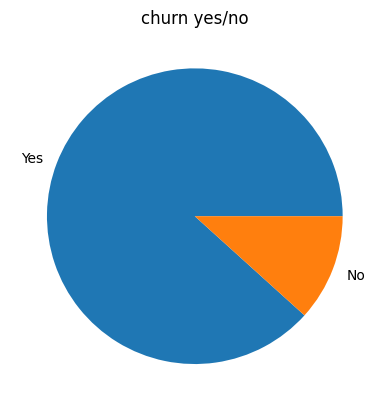

In [13]:
import matplotlib.pyplot as plt
df["Churn"].value_counts().plot(kind="pie")
plt.title("churn yes/no")
plt.ylabel("")
plt.show()

In [14]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [15]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [16]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [17]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [18]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

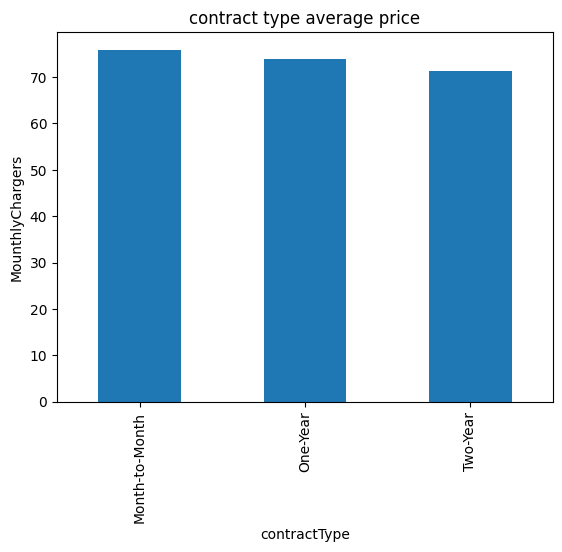

In [19]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind = "bar")
plt.ylabel("MounthlyChargers")
plt.xlabel("contractType")
plt.title("contract type average price")
plt.show()

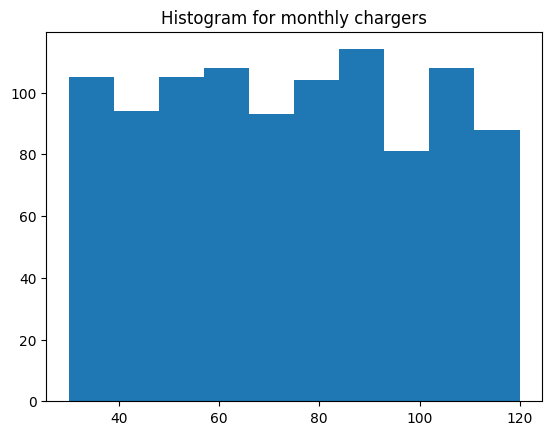

In [20]:
plt.hist(df["MonthlyCharges"])
plt.title("Histogram for monthly chargers")
plt.show()

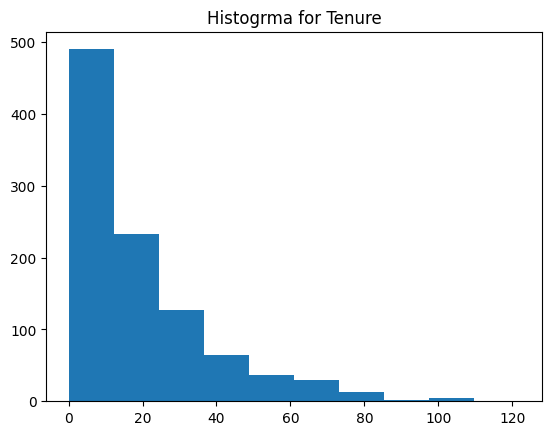

In [21]:
plt.hist(df["Tenure"])
plt.title("Histogrma for Tenure")
plt.show()

In [22]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='str')

In [23]:
y = df[["Churn"]]
x = df[["Age","Gender","Tenure","MonthlyCharges"]]

In [24]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [25]:
x["Gender"] = x["Gender"].apply(lambda x:1 if x == "Female" else 0)
x.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [26]:
y["Churn"] = y["Churn"].apply(lambda x:1 if x == "Yes" else 0)

In [27]:
y.value_counts()

Churn
1        883
0        117
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler 

In [30]:
scaler = StandardScaler()

In [31]:
x_train = scaler.fit_transform(x_train)

In [32]:
import joblib
joblib.dump(scaler,"Scaler.pkl")

['Scaler.pkl']

In [33]:
x_test = scaler.fit_transform(x_test)

In [34]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test,predictions)))

In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
Log_model = LogisticRegression()

In [38]:
Log_model.fit(x_train, y_train)

C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [39]:
y_pred = Log_model.predict(x_test)

In [40]:
modelperformance(y_pred)

Accuracy score on model is 0.875


In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
param_grid = {
    "n_neighbors":[3,5,7,9],
    "weights" :  ["uniform","distance"],
}


In [43]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid, cv=5)

In [44]:
gridkn.fit(x_train,y_train)

C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [45]:
gridkn.best_params_

{'n_neighbors': 7, 'weights': 'distance'}

In [46]:
y_pred = gridkn.predict(x_test)

In [47]:
modelperformance(y_pred)

Accuracy score on model is 0.87


In [48]:
from sklearn.svm import SVC

In [49]:
svm = SVC()

In [50]:
param_grid = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear","rbf","poly"]
}

In [51]:
gridsvc = GridSearchCV(svm, param_grid, cv=5)

In [52]:
gridsvc.fit(x_train,y_train)

C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python3

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [53]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [54]:
y_pred = gridsvc.predict(x_test)

In [55]:
modelperformance(y_pred)

Accuracy score on model is 0.885


In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
param_grid = {
    "criterion" : ["gini","entropy"],
    "splitter" : ["best","random"],
    "max_depth" : [None, 10, 20, 30],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf" : [1,2,4]
}

In [58]:
grid_tree = GridSearchCV(DecisionTreeClassifier(),param_grid,cv = 5)

In [59]:
grid_tree.fit(x_train,y_train)

C:\Users\Manjitha S Kariyawas\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [60]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 30,
 'min_samples_leaf': 4,
 'min_samples_split': 5,
 'splitter': 'random'}

In [61]:
y_pred = grid_tree.predict(x_test)

In [62]:
modelperformance(y_pred)

Accuracy score on model is 0.84


In [75]:
best_model = gridsvc.best_estimator_

In [76]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [77]:
x.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='str')